In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [ ]:
import os
np.set_printoptions(legacy='1.25')
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
atom1, atom2 = 'Rb', 'Cs'
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')
change1 = 0
change2 = 0

energy_unit = 'GHz'

min_n = 40
max_n = 91
ns = np.arange(min_n,max_n)
preferQuantumDefects = True


js = [[1/2], [1/2, 3/2], [3/2, 5/2], [5/2, 7/2]]

l1, l2 = 1, 1


for j1 in js[l1]:
    for j2 in js[l2]:
        for l1_1 in (l1-1, l1+1):
            if l1_1 < 0:
                continue
            for l2_1 in (l2-1, l2+1):
                if l2_1 < 0:
                    continue
                            
                for j1_1 in js[l1_1]:
                    if abs(j1_1 - j1) > 1:
                        continue

                    for j2_1 in js[l2_1]: 
                        if abs(j2_1 - j2) > 1:
                            continue 
                        path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\C3s\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\'
                        if not os.path.exists(path):
                            os.makedirs(path)
                        if os.path.exists(path + f'{j1_1}, {j2_1} {change1} {change2}.csv'):
                            continue
                        c3ks = []
                        n1s=[]
                        n2s=[]
                        for n1 in ns:
                            for n2 in ns:


                            
                            # Rb lowering n
                                if atom1 == 'Rb':
                                    rb_matrix_element_j = arc.Rubidium().getReducedMatrixElementJ(n1, l1, j1, n1+change1, l1_1, j1_1)     
                                else:
                                    rb_matrix_element_j = arc.Caesium().getReducedMatrixElementJ(n1, l1, j1, n1+change1, l1_1, j1_1)
                                if atom2 == 'Rb':
                                    cs_matrix_element_j = arc.Rubidium().getReducedMatrixElementJ(n2, l2, j2, n2+change2, l2_1, j2_1)     
                                else:
                                    cs_matrix_element_j = arc.Caesium().getReducedMatrixElementJ(n2, l2, j2, n2+change2, l2_1, j2_1)

                                c3k = (a_0[0]*e) **2 / h / (4*np.pi*epsilon_0) * 1e9 * cs_matrix_element_j * rb_matrix_element_j/np.sqrt(2*j1_1+1)/np.sqrt(2*j2_1+1)

                                n1s.append(n1)
                                n2s.append(n2)
                                c3ks.append(c3k)
                                
                        c3k_data = pd.DataFrame({'n1s' : n1s, 'n2s' : n2s, 'c3k' : c3ks})
                        
                        
                        # os.path.join(path + f'j1_1, j2_1 dif  change1  change2.txt')
                        if not os.path.exists(path + 'j1_1, j2_1 change1 change2.txt'):
                            with open(path + 'j1_1, j2_1 change1 change2.txt', "w") as file:
                                file.write("")

                        c3k_data.to_csv(path + f'{j1_1}, {j2_1} {change1} {change2}.csv', index=False)
                    print(f'j1s: {int(list(js[l1]).index(j1)/len(js[l1])*100)}% | j2s: {int(list(js[l2]).index(j2)/len(js[l2])*100)}% | l1_1, l2_1: {l1_1},{l2_1}')
                                    
                                    

j1s: 0% | j2s: 0% | l1_1, l2_1: 0,0
j1s: 0% | j2s: 0% | l1_1, l2_1: 0,2
j1s: 0% | j2s: 0% | l1_1, l2_1: 2,0
j1s: 0% | j2s: 0% | l1_1, l2_1: 2,2
j1s: 0% | j2s: 50% | l1_1, l2_1: 0,0
j1s: 0% | j2s: 50% | l1_1, l2_1: 0,2
j1s: 0% | j2s: 50% | l1_1, l2_1: 2,0
j1s: 0% | j2s: 50% | l1_1, l2_1: 2,2
j1s: 50% | j2s: 0% | l1_1, l2_1: 0,0
j1s: 50% | j2s: 0% | l1_1, l2_1: 0,2
j1s: 50% | j2s: 0% | l1_1, l2_1: 2,0
j1s: 50% | j2s: 0% | l1_1, l2_1: 2,0
j1s: 50% | j2s: 0% | l1_1, l2_1: 2,2
j1s: 50% | j2s: 0% | l1_1, l2_1: 2,2
j1s: 50% | j2s: 50% | l1_1, l2_1: 0,0


[0.79454867 0.83883959 0.88433137 0.931024   0.97891749 1.02801183
 1.07830702 1.12980307 1.18249997 1.23639773 1.29149634 0.83771278
 0.88440982 0.93237296 0.98160218 1.03209749 1.0838589  1.1368864
 1.19117998 1.24673966 1.30356543 1.36165729 0.8820182  0.93118498
 0.98168482 1.03351771 1.08668365 1.14118264 1.19701468 1.25417978
 1.31267793 1.37250913 1.43367339 0.92746494 0.97916508 1.03226697
 1.08677059 1.14267595 1.19998304 1.25869188 1.31880246 1.38031478
 1.44322883 1.50754463 0.97405299 1.02835012 1.08411939 1.14136082
 1.20007439 1.26026012 1.321918   1.38504802 1.4496502  1.51572453
 1.58327102 1.02178236 1.07874009 1.1372421  1.1972884  1.25887899
 1.32201386 1.38669302 1.45291647 1.52068421 1.58999623 1.66085255
 1.07065304 1.13033499 1.19163509 1.25455333 1.31908973 1.38524427
 1.45301696 1.52240781 1.5934168  1.66604394 1.74028922 1.12066504
 1.18313483 1.24729836 1.31315562 1.38070662 1.44995135 1.52088982
 1.59352202 1.66784796 1.74386764 1.82158105 1.17181835 1.23713

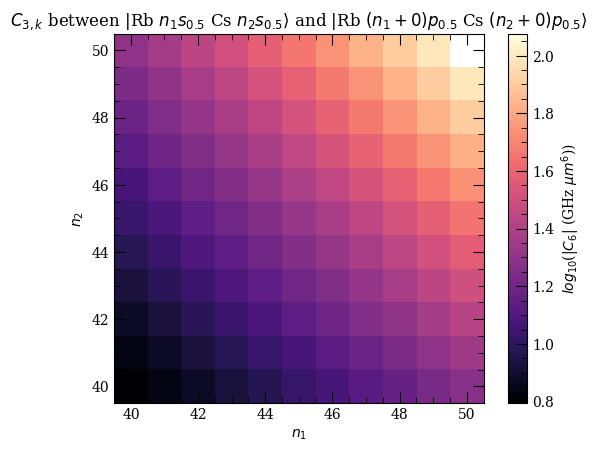

In [71]:
from pairinteraction.visualization.colormaps import alphamagma
l1, l2 = 0, 0
j1, j2 = 1/2, 1/2
l1_1, l2_1 = 1, 1
j1_1, j2_1 = 1/2, 1/2

change1, change2 = 0,0


plot_n1s=[]
plot_n2s=[]
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')
c3k_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\C3s\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {change1} {change2}.csv'
c3k_data = pd.read_csv(c3k_path)
n1s = c3k_data['n1s'].to_numpy()
n2s = c3k_data['n2s'].to_numpy()
c3k = c3k_data['c3k'].to_numpy()
print(c3k)
red_n1s = np.arange(min(n1s), max(n1s)+1)
red_n2s = np.arange(min(n2s), max(n2s)+1)

# print(n1s)
X, Y = np.meshgrid(n1s, n2s)
Z = np.zeros((max(n1s)-min(n1s)+1,max(n2s)-min(n2s)+1))
for i, n1 in enumerate(n1s):
    Z[list(red_n2s).index(n2s[i]), list(red_n1s).index(n1)] = c3k[i]

# print(Z)
ax.set_aspect('equal', adjustable='box')

cmap = ax.imshow(Z, cmap=alphamagma.reversed(), extent=(min(n1s)-0.5, max(n1s)+0.5, min(n2s)-0.5, max(n2s)+0.5), origin='lower')

col = 0
# for l1_1 in [l1-1, l1+1]:
#     for l2_1 in [l2-1, l1+1]:
#         path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\spreadsheets\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]} to {orbs[l1_1]}{orbs[l2_1]} j1j2({j1},{j2}).xlsx'
#         if os.path.exists(path):
#             df = pd.read_excel(path)
#             plot_n1s = df['n1_0'].to_numpy()
#             plot_n2s = df['n2_0'].to_numpy()
#             ax.plot(plot_n1s, plot_n2s, 'o', markerfacecolor='none', markersize=8, color=colours[col], markeredgewidth=2, label = f'{orbs[l1_1]} {orbs[l2_1]}')
#             col+=1
#         else:
#             continue
# print(df['n1_0'])
# np.concatenate(plot_n1s).flatten()
# np.concatenate(plot_n2s).flatten()
print(plot_n1s)

# plt.legend()

cbar = plt.colorbar(cmap, label=r'$log_{10}$(|$C_6$| (GHz $\mu m^6$))')
# cbar.set_ticks(np.arange(-2,6))
plt.xlabel(r'$n_1$')
plt.ylabel(r'$n_2$')
plt.title(rf'$C_{{3,k}}$ between |{atom1} $n_1{orbs[l1]}_{{{j1}}}$ {atom2} $n_2{orbs[l2]}_{{{j2}}}\rangle$ and |{atom1} $(n_1+{change1}){orbs[l1_1]}_{{{j1_1}}}$ {atom2} $(n_2+{change2}){orbs[l2_1]}_{{{j2_1}}}\rangle$')
plt.show()